<a href="https://colab.research.google.com/github/yanchenliu-cxk/ESM/blob/main/Leiden-650M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 安装支持 Colab CUDA 12 的 RAPIDS 加速库 (cuML 提供 UMAP 加速，cuGraph 为后续图计算提供支持)
!pip install cudf-cu12 cuml-cu12 cugraph-cu12 --extra-index-url=https://pypi.nvidia.com

# 安装用于执行 Leiden 拓扑聚类的生态库
!pip install scanpy anndata

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of cugraph-cu12 to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 235.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 87.7 MB/s et

In [2]:
# 安装支持 Colab CUDA 12 的 RAPIDS 加速库
!pip install cudf-cu12 cuml-cu12 cugraph-cu12 --extra-index-url=https://pypi.nvidia.com

# 安装用于执行 Leiden 拓扑聚类的生态库
!pip install scanpy anndata

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 34.3 MB/s eta 0:00:00
正在将特征矩阵载入 A100 GPU...
载入完成！当前 GPU 矩阵形状: (5252, 1280)
启动 GPU 级 UMAP 降维计算...


/usr/local/lib/python3.12/dist-packages/cuml/internals/outputs.py:417: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)


UMAP 降维完成！
正在构建 K-近邻网络拓扑图...
正在运行 Leiden 算法划分独立“功能储库”...


/tmp/ipykernel_520/91673355.py:41: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.5)


聚类完成，海量序列已被成功划分为 80 个潜在酶家族储库。


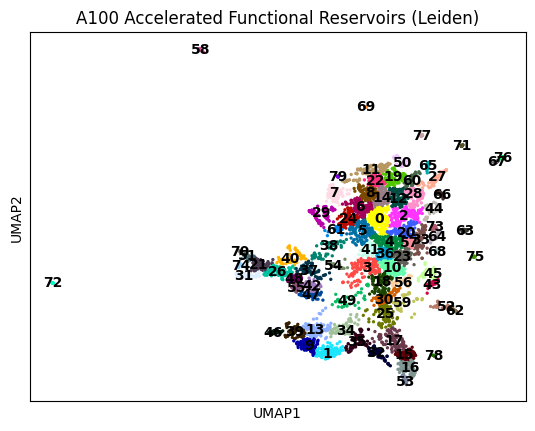

In [4]:
import numpy as np
import cupy as cp
from cuml.manifold import UMAP
import scanpy as sc
import anndata as ad

# Install leidenalg for Scanpy's Leiden clustering
!pip install leidenalg

# 1. 载入您的 ESM-2 特征矩阵
# /content/nocardioides_esm2_650M_embeddings.npy 是您计算出的 650M 模型特征，形状为 (序列总数, 1280)
esm2_embeddings_cpu = np.load('/content/nocardioides_esm2_650M_embeddings.npy') # Load the data first
# A100 显存极大，但为了极致的计算效率，仍建议保持 float32 格式
esm2_embeddings_cpu = esm2_embeddings_cpu.astype(np.float32)

# 将海量特征瞬间转移至 A100 的 80GB 显存中
print("正在将特征矩阵载入 A100 GPU...")
X_gpu = cp.asarray(esm2_embeddings_cpu)
print(f"载入完成！当前 GPU 矩阵形状: {X_gpu.shape}")

# 2. 执行 GPU 级 UMAP 降维
print("启动 GPU 级 UMAP 降维计算...")
umap_model = UMAP(
    n_neighbors=15,
    n_components=2,
    build_algo='nn_descent', # 此参数在处理海量数据时能提供数百倍的加速
    random_state=42
)
X_reduced_gpu = umap_model.fit_transform(X_gpu)
print("UMAP 降维完成！")

# 3. 数据转回 CPU 并构建 AnnData 对象
X_reduced_cpu = X_reduced_gpu.get()
adata = ad.AnnData(X=X_reduced_cpu)

# 4. 构建网络拓扑图与 Leiden 聚类
print("正在构建 K-近邻网络拓扑图...")
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')

print("正在运行 Leiden 算法划分独立“功能储库”...")
sc.tl.leiden(adata, resolution=1.5)
cluster_labels = adata.obs['leiden'].values
print(f"聚类完成，海量序列已被成功划分为 {len(set(cluster_labels))} 个潜在酶家族储库。")

# 5. 可视化修复与呈现
# 将 UMAP 坐标明确赋予 scanpy 的结构中，避免之前遇到的 KeyError 绘图报错
adata.obsm['X_umap'] = X_reduced_cpu

# 绘制高解析度的流形聚类图
sc.pl.umap(
    adata,
    color='leiden',
    title='A100 Accelerated Functional Reservoirs (Leiden)',
    legend_loc='on data' # 簇标签直接写在图上的对应位置，方便您寻找 DONepi 所在的靶向区域
)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0
  libkpathsea6 libptexenc1 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lmodern poppler-data t1utils tex-common tex-gyre
  texlive-base texlive-binaries texlive-latex-base tipa xfonts-encodings
  xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf poppler-utils ghostscript
  fonts-japanese-mincho | fonts-ipafont-mincho fonts-japanese-gothic
  | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-uming fonts-nanum
  debhelper gv | postscript-viewer perl-tk xpdf | pdf-viewer xzdec
  texlive-fonts-recommended-doc texlive-latex-base-doc tipa-doc
The following NEW packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lmodern 

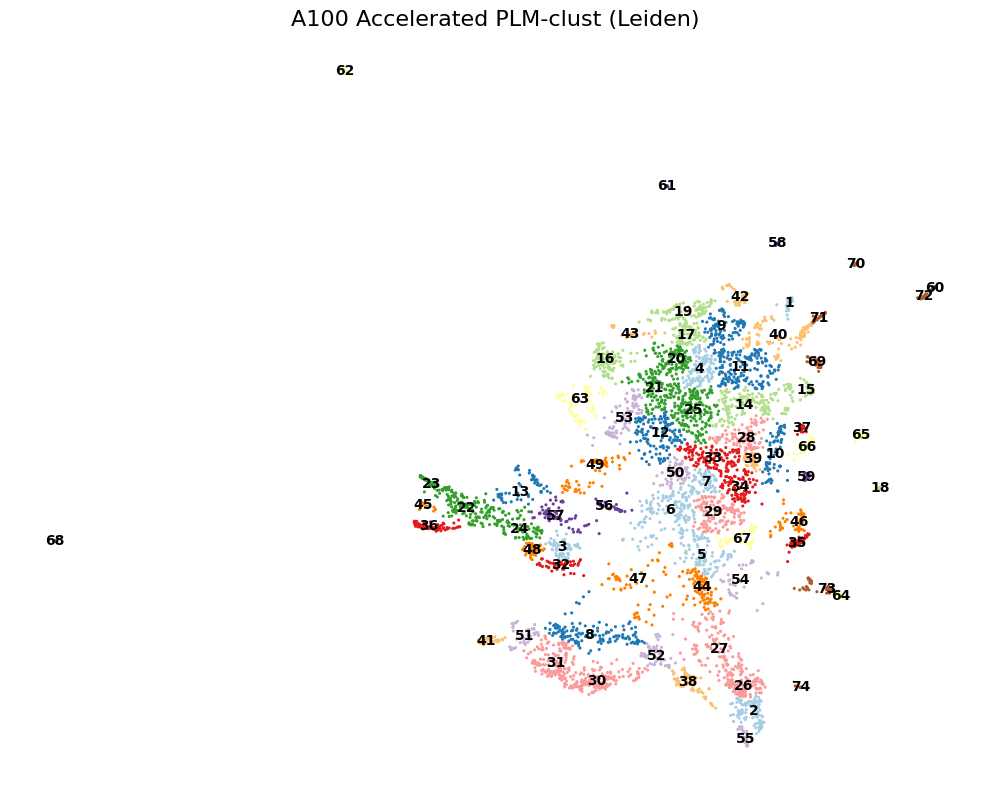

In [9]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt # Import matplotlib for finer control and saving
import matplotlib

# Install 'Times New Roman' font
!sudo apt-get install -y texlive-fonts-recommended
!sudo fc-cache -f -v

# Set font family globally for matplotlib plots to Times New Roman
matplotlib.rcParams['font.family'] = 'Times New Roman'

# 1. 将降维结果从 GPU 取回 CPU
X_reduced_cpu = X_reduced_gpu.get()

# 2. 构建 AnnData 对象
adata = ad.AnnData(X=X_reduced_cpu)

# 3. 构建 K-近邻图 (这是 Leiden 聚类的前置条件)
print("正在构建网络拓扑图...")
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X')

# 4. 执行 Leiden 无监督聚类
print("正在执行 Leiden 聚类划分功能储库...")
# Use igraph implementation for better performance and to address FutureWarning
sc.tl.leiden(adata, resolution=1.5, flavor='igraph', n_iterations=2, directed=False)

# 5. 提取聚类结果并转换为1-indexed标签
cluster_labels = adata.obs['leiden'].values
adata.obs['leiden_1_indexed'] = (adata.obs['leiden'].astype(int) + 1).astype(str)
print(f"成功将序列空间划分为 {len(set(cluster_labels))} 个潜在功能储库！(已重新编号为1开始)")

# ==========================================
# 修复之前的可视化报错问题
# 必须将 UMAP 坐标手动放入 adata.obsm['X_umap'] 中，scanpy 才能识别
adata.obsm['X_umap'] = X_reduced_cpu

# 直接使用 scanpy 绘制极其精美的流形聚类图
# Optimized for Nature standards
# Create a figure and axes object to control size and saving
fig = plt.figure(figsize=(10, 8)) # Set figure size for publication
ax = fig.add_subplot(111)

sc.pl.umap(
    adata,
    color='leiden_1_indexed', # Use 1-indexed labels for coloring
    title='A100 Accelerated PLM-clust (Leiden)', # Keep title here for sc.pl.umap to set it
    legend_loc='on data', # Keep legend on data as per previous request
    frameon=False,        # Remove the surrounding frame
    size=20,              # Adjust marker size for better visibility (increased from 10 to 20)
    palette='Paired',     # Use a 'Paired' color palette for better aesthetics
    legend_fontsize=10,   # Larger legend font size (for 'on data' labels)
    legend_fontweight='bold', # Bold legend text
    ax=ax,                # Pass the axes object
    show=False            # Do not display immediately
)

# After sc.pl.umap, adjust font sizes on the ax object
ax.set_title(ax.get_title(), fontsize=16) # Set title font size
ax.tick_params(axis='both', which='major', labelsize=12) # Set tick label font size
ax.set_xlabel(ax.get_xlabel(), fontsize=12) # Set x-label font size
ax.set_ylabel(ax.get_ylabel(), fontsize=12) # Set y-label font size

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('umap_leiden_nature_standard_enhanced.pdf', dpi=300, bbox_inches='tight') # Save as high-res PDF
plt.show() # Display the plot

### Publication-Quality UMAP Plotting with Advanced Customization

This section generates UMAP plots tailored for publication, incorporating font customizations, specific color palettes, and two distinct visualization strategies: a comprehensive overview for many clusters and a 'target highlight' approach for focusing on specific clusters.


Generating UMAP Overview Plot...


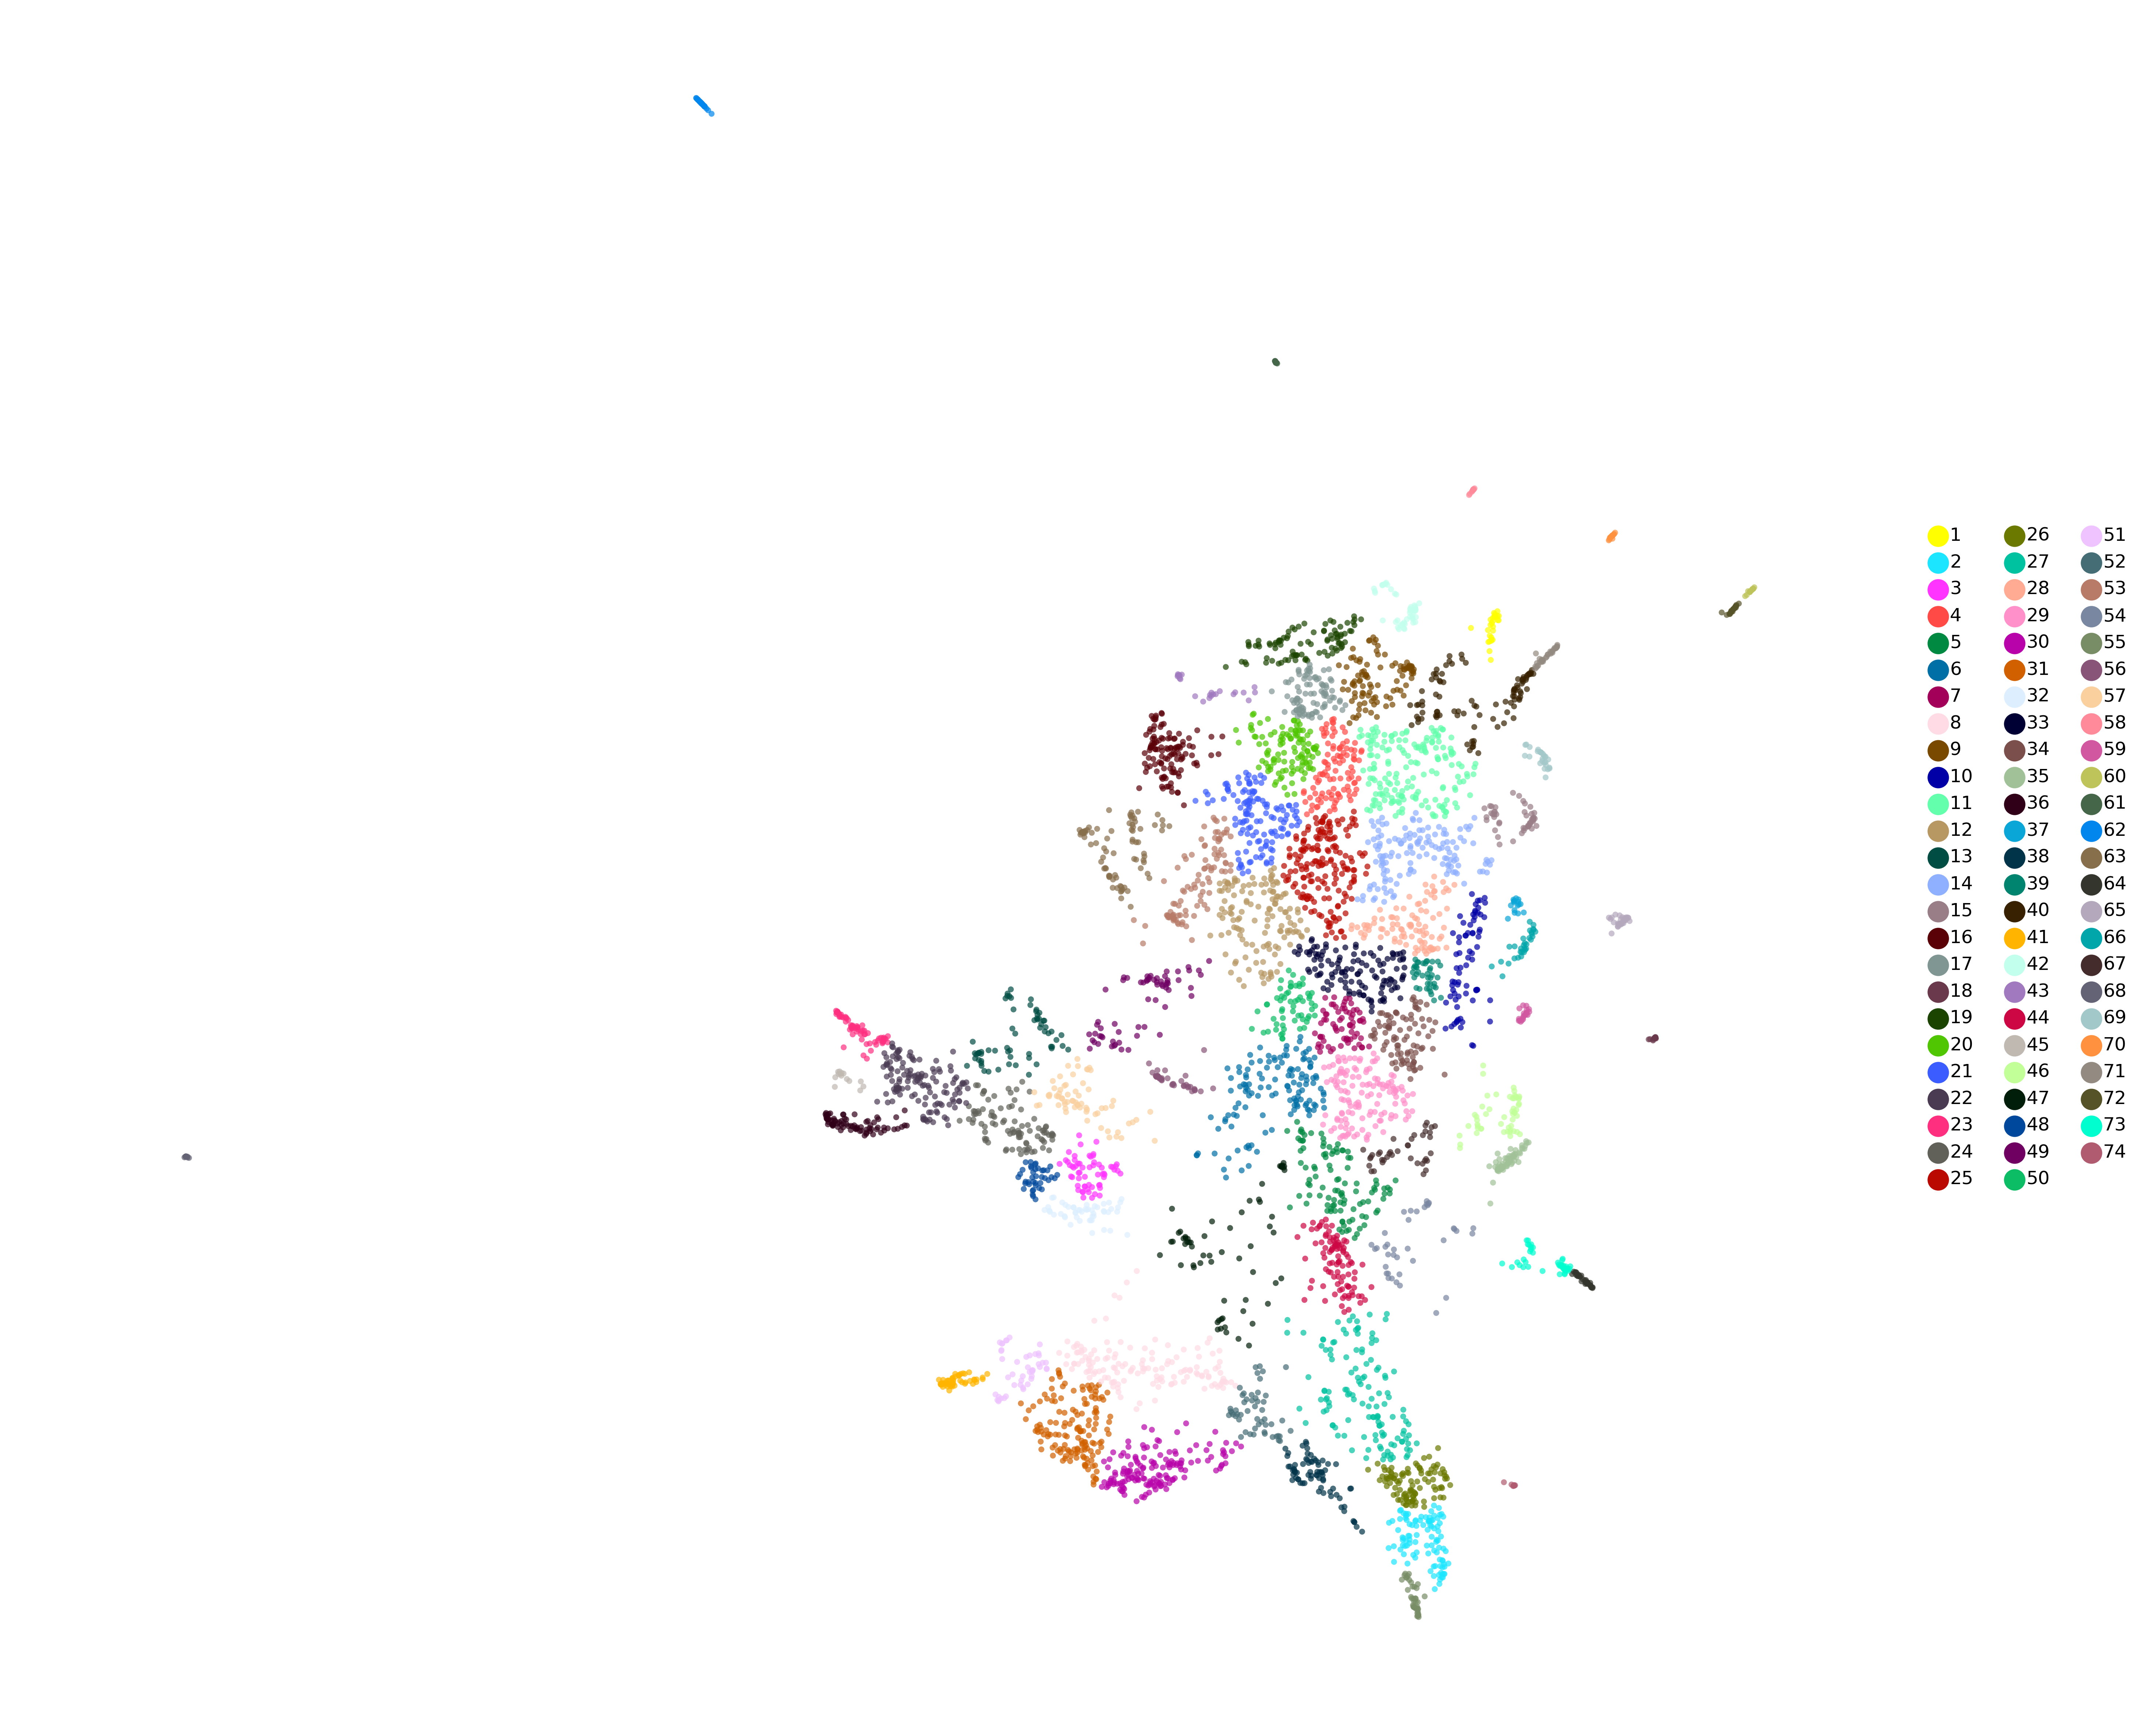

UMAP Overview Plot saved as UMAP_Overview_Publication.pdf
Generating UMAP Target Highlight Plot...


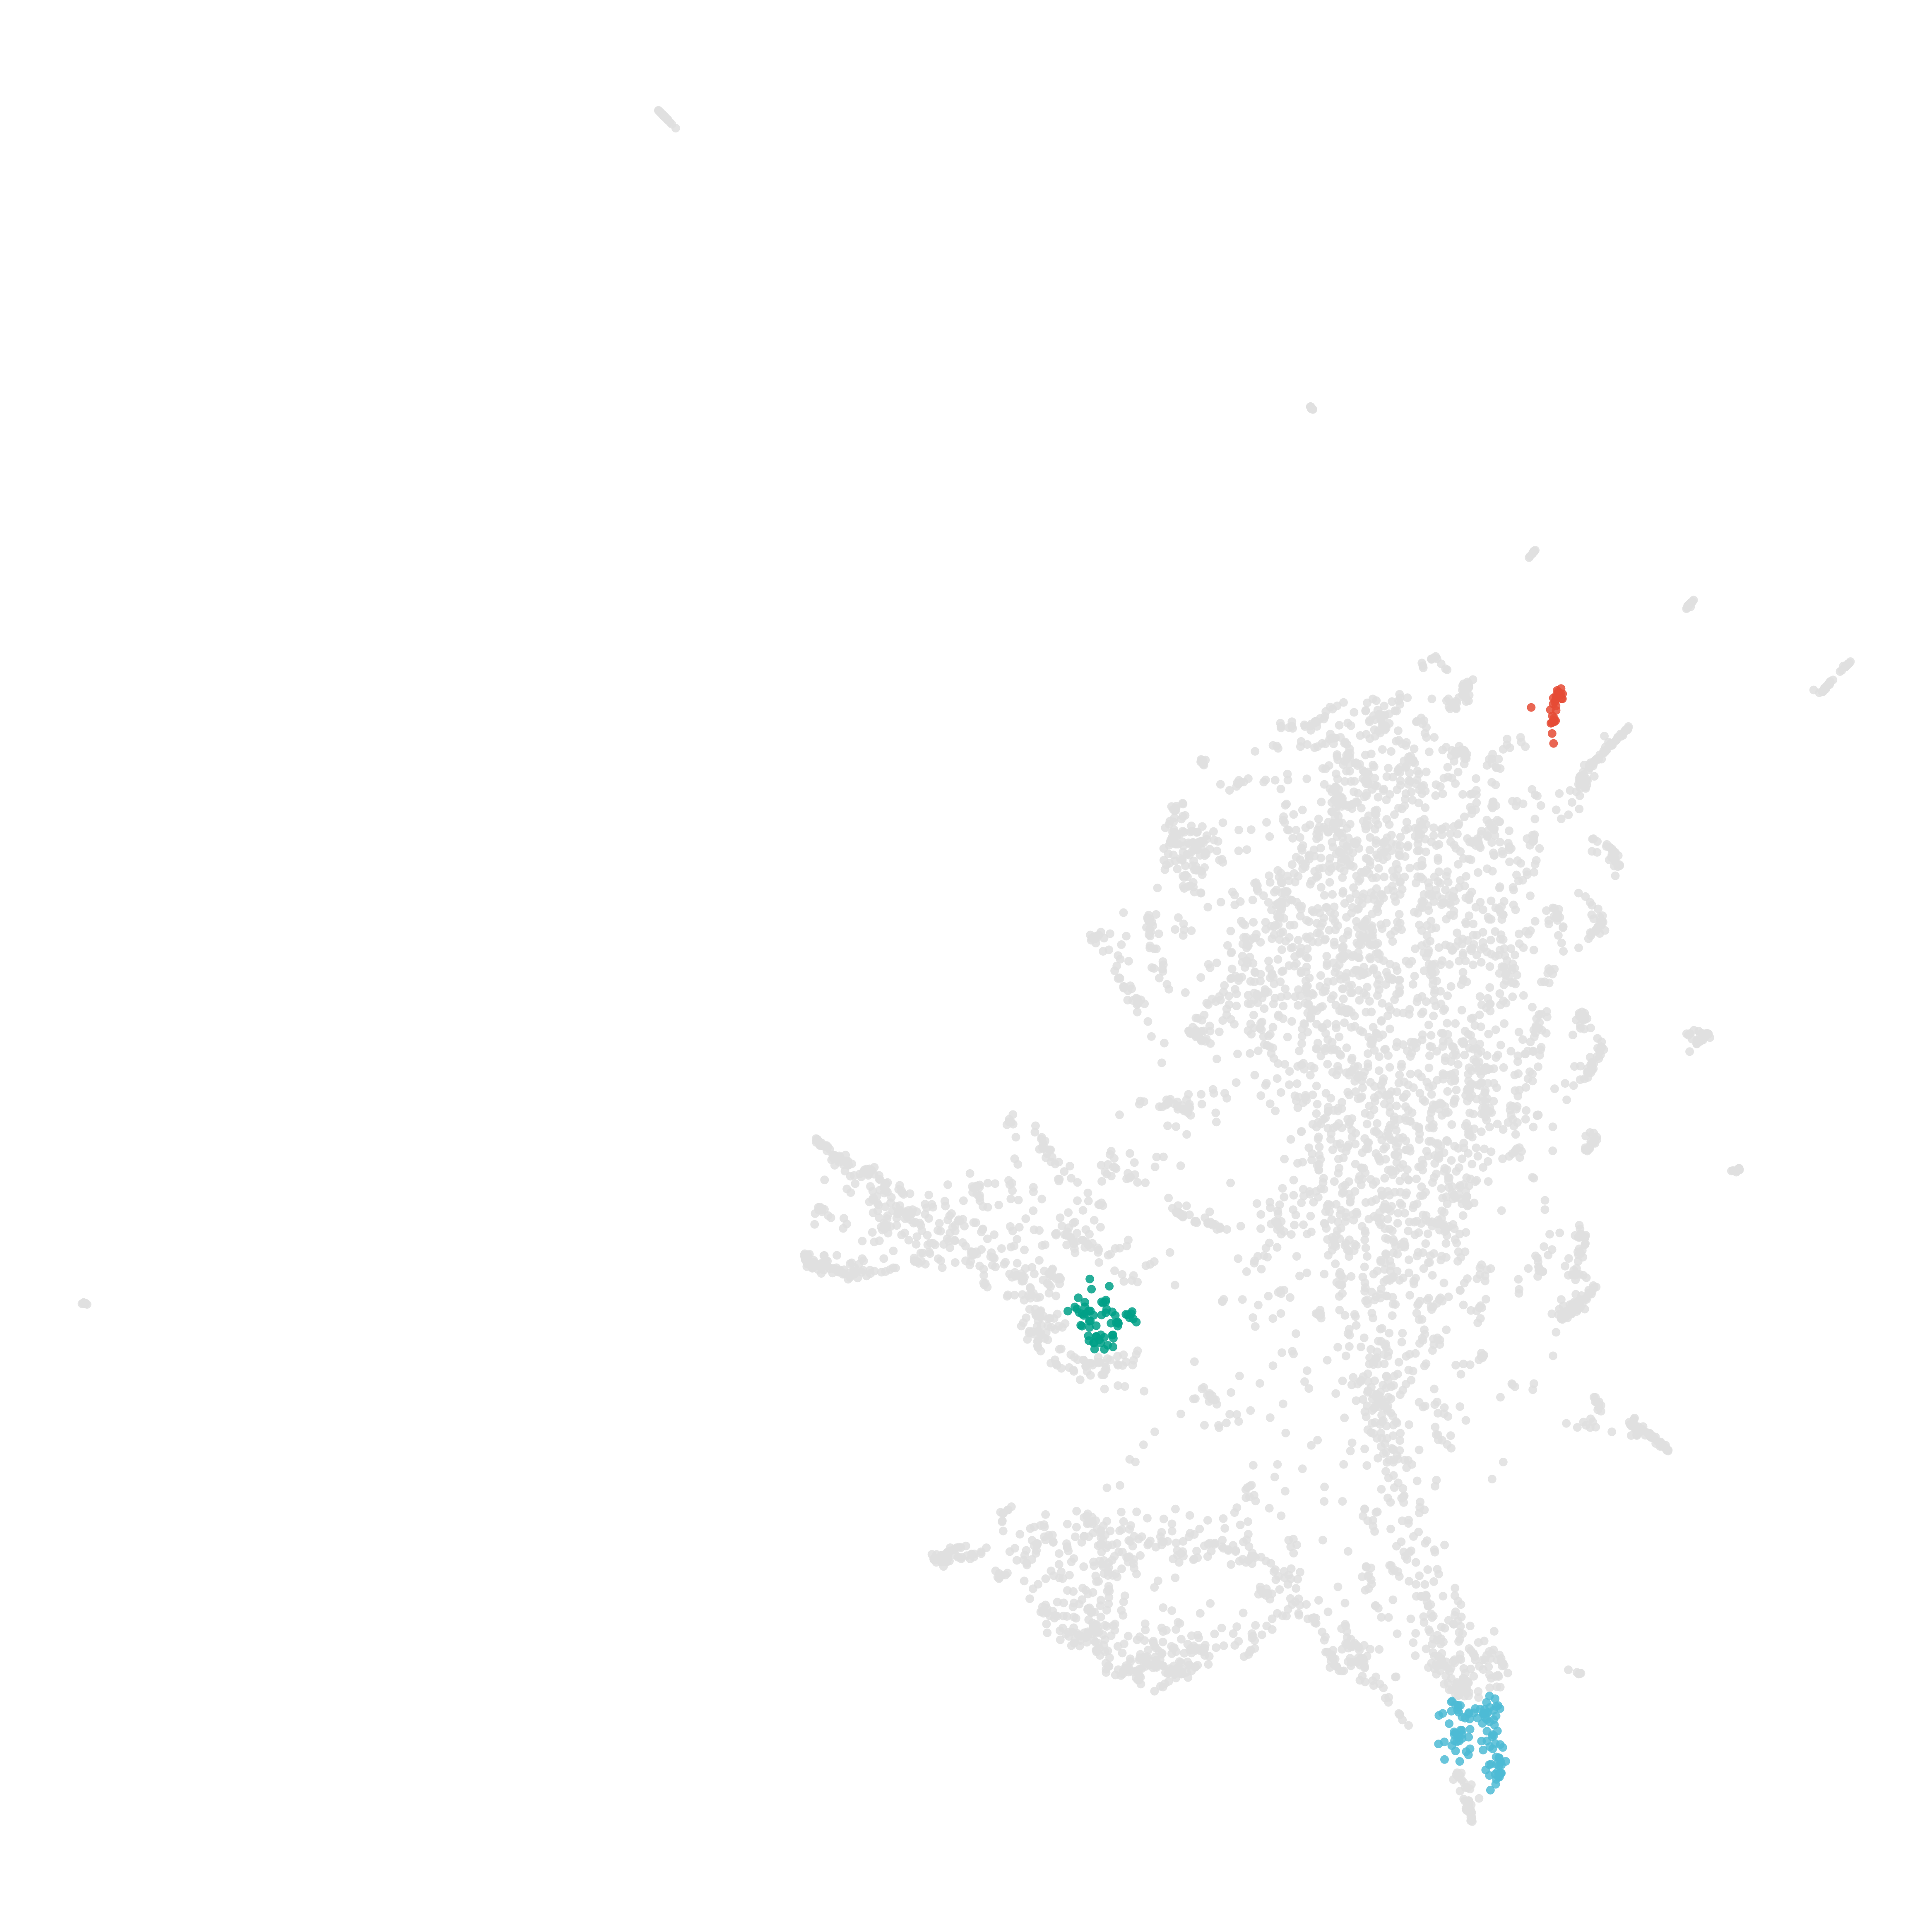

UMAP Target Highlight Plot saved as UMAP_Highlight_Target_NatureStyle.pdf


In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import scanpy as sc
import seaborn as sns
import numpy as np

# Ensure leiden_clusters is correctly assigned from the 1-indexed labels
# Assuming adata.obs['leiden_1_indexed'] was created in the previous steps
adata.obs['leiden_clusters'] = adata.obs['leiden_1_indexed'].astype('category')

# ==========================================
# 1. 顶级期刊全局排版与字体规范设置
# ==========================================
# 使用无衬线字体 (Nature/Science 强烈推荐)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'] # Preferred sans-serif fonts

# 关键：导出为可编辑的 PDF 矢量图格式，保证文本在 Adobe Illustrator 中不被转为轮廓
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# 极简坐标轴：移除顶部和右侧边框，加粗剩余边框
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = False
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.direction'] = 'out'
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2

# ==========================================
# 2. 经典期刊配色方案字典 (Hex Codes)
# ==========================================
# Nature 经典高对比度配色 (NPG)
nature_palette = ['#e64b35', '#4dbbd5', '#00a087', '#3c5488', '#f39b7f',
                  '#8491b4', '#91d1c2', '#dc0000', '#7e6148', '#b09c85']

# Cell 经典高亮配色 (example, can be expanded)
cell_palette = ['#D1391D', '#32669C', '#61A75C', '#84428B', '#F1B631', '#1D9AD1', '#DF7322', '#6A9237', '#93542B', '#E54C28']

# 设置高分辨率输出
# Note: sc.set_figure_params applies to subsequent scanpy plotting functions
sc.set_figure_params(dpi=300, dpi_save=300, figsize=(8, 8), frameon=False)

# ==========================================
# 3. 策略 A：全景超多簇高质量展示 (解决拥挤问题)
# ==========================================
print("Generating UMAP Overview Plot...")
fig, ax = plt.subplots(figsize=(10, 8))

# 由于您的簇多达 78 个，使用超大离散色板，并把标签移到图外
sc.pl.umap(
    adata,
    color='leiden_clusters',
    palette=sc.pl.palettes.godsnot_102, # Scanpy内置的高对比度大色板，避免颜色过早循环
    size=15,             # 大幅减小点的大小，体现局部的流形密度
    alpha=0.7,           # 增加透明度，避免重叠区域变成死黑
    legend_loc='right margin', # 将拥挤的图例移到右侧空白处
    legend_fontsize=6,   # 缩小图例字体
    legend_fontweight='normal',
    title='',            # 顶级期刊的图内通常不写 Title，而在图注中说明
    ax=ax,
    show=False
)

ax.set_xlabel('UMAP 1', fontweight='bold', fontsize=12)
ax.set_ylabel('UMAP 2', fontweight='bold', fontsize=12)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
# 建议保存为 pdf 后在 AI 中进行细节微调
plt.savefig('UMAP_Overview_Publication.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("UMAP Overview Plot saved as UMAP_Overview_Publication.pdf")

# ==========================================
# 4. 策略 B：Nature 偏爱的 "Target Highlight" (灰底高亮) 策略
# ==========================================
# 顶级期刊极少在一张图里同时展示几十种鲜艳的颜色。
# 标准做法是：将所有背景序列设为浅灰色，只用 Nature 的核心颜色高亮你的目标酶（如DONepi）及其邻近簇。

# 假设通过上图，您发现 DONepi 所在的簇是 '15'，您想挖掘的相邻未知簇是 '16' 和 '17'
# Adjust these based on your actual cluster labels (now 1-indexed)
target_clusters = ['1', '2', '3'] # Example target clusters, adjust as needed

# Create a new color mapping dictionary
highlight_colors = {}
# Ensure all categories are covered, including those not in target_clusters
for cluster_id in adata.obs['leiden_clusters'].cat.categories:
    if cluster_id == target_clusters[0]:
        highlight_colors[cluster_id] = nature_palette[0] # Example color for target 1
    elif cluster_id == target_clusters[1]:
        highlight_colors[cluster_id] = nature_palette[1] # Example color for target 2
    elif cluster_id == target_clusters[2]:
        highlight_colors[cluster_id] = nature_palette[2] # Example color for target 3
    else:
        highlight_colors[cluster_id] = '#E0E0E0'         # Light gray for other clusters

print("Generating UMAP Target Highlight Plot...")
fig, ax = plt.subplots(figsize=(8, 8))

# 绘制高亮图：背景点先画（透明度高），目标点后画（不透明）
# Scanpy 处理自定义字典调色板非常方便
sc.pl.umap(
    adata,
    color='leiden_clusters',
    palette=highlight_colors,
    size=25,
    alpha=0.85,
    legend_loc='none', # 隐藏图例，后期在 AI 里手动拉线标注
    title='',
    ax=ax,
    show=False
)

ax.set_xlabel('UMAP 1', fontweight='bold', fontsize=14)
ax.set_ylabel('UMAP 2', fontweight='bold', fontsize=14)
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.savefig('UMAP_Highlight_Target_NatureStyle.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("UMAP Target Highlight Plot saved as UMAP_Highlight_Target_NatureStyle.pdf")

In [11]:
import pandas as pd

# ==========================================
# 储存方案一：保存为完整的 AnnData 对象 (.h5ad 格式)
# 强烈推荐：这将完整保留您的 ESM-2 特征矩阵、UMAP 坐标和 Leiden 分类标签。
# 下次计算时，只需使用 adata = sc.read_h5ad('ESM2_Leiden_Clustering_Result.h5ad') 即可瞬间恢复所有数据。
# ==========================================
adata.write_h5ad('ESM2_Leiden_Clustering_Result.h5ad')
print("已成功保存为完整数据包: ESM2_Leiden_Clustering_Result.h5ad")

# ==========================================
# 储存方案二：提取核心结果并导出为 CSV 文件
# 推荐用途：方便您直接查看，或者将特定簇的标签输入给后续的反应条件网络。
# ==========================================
# 创建一个 DataFrame，将坐标和簇标签对齐
result_df = pd.DataFrame({
    'Sequence_ID': adata.obs_names,  # 如果您的序列有具体的 ID 或名称，它们保存在这里
    'UMAP_1': adata.obsm['X_umap'][:, 0],
    'UMAP_2': adata.obsm['X_umap'][:, 1],
    'Leiden_Cluster': adata.obs['leiden_clusters']
})

# 导出为 CSV 文件
result_df.to_csv('ESM2_Cluster_Labels.csv', index=False)
print("已成功导出聚类结果至表格: ESM2_Cluster_Labels.csv")

已成功保存为完整数据包: ESM2_Leiden_Clustering_Result.h5ad
已成功导出聚类结果至表格: ESM2_Cluster_Labels.csv
